# 02 — Data Exploration

Class balance, sentence length distribution, sample inspection. Pure EDA — no model training.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import matplotlib.pyplot as plt
from src import data, viz, config as C

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = data.load_processed()
print(f'{len(df)} rows')
df.head()

3120 rows


,text,label
0,NYPD Commissioner Dermot Shea on Monday expres...,0
1,School systems across the country are adopting...,1
2,"And then along came President Barry Obama, who...",1
3,"The curfews, which have never before occurred ...",1
4,"Rather than help be a part of the solution, Tr...",1


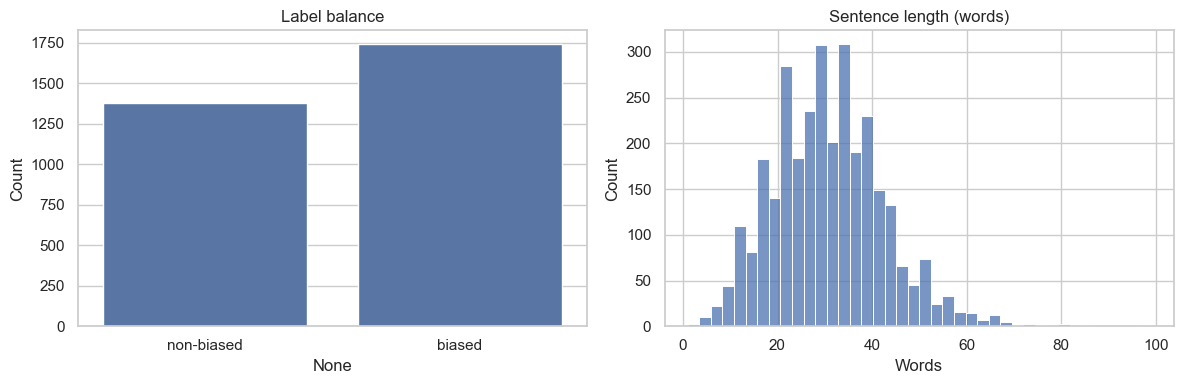

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
viz.plot_label_balance(df, ax=axes[0])
viz.plot_length_distribution(df, ax=axes[1])
plt.tight_layout()
plt.savefig(C.RESULTS_DIR / 'eda_overview.png', dpi=150)
plt.show()

In [4]:
print('--- Biased samples ---')
for s in df[df[C.LABEL_COL] == 1][C.TEXT_COL].sample(5, random_state=C.SEED):
    print('-', s)
print()
print('--- Non-biased samples ---')
for s in df[df[C.LABEL_COL] == 0][C.TEXT_COL].sample(5, random_state=C.SEED):
    print('-', s)

--- Biased samples ---
- The irony of these radicalized, educated women announcing their privilege and “white guilt” as if it’s something to brag about is that doing so loudly and violently as they have in recent weeks is perhaps the highest form of white privilege.
- As it has played out on the ground, these gatherings have become bellicose, and frequently armed, mobs protesting police officers at their homes, breaking into health-board meetings that were being held online, and breaking down the doors inside the Statehouse and attending committee meetings unmasked in order to intimidate state legislators.
- Some 20 million may have shown up to BLM rallies in the last month, but the hardcore activists behind these rallies—the true-believing cult members and leaders—are relatively small in number.
- Her call for a Green New Deal -- which would seek to focus on income inequality and climate change by funding a host of radical ideas on liberal wish-lists and overhaul the nation's energy s

In [5]:
# Length stats
lens = df[C.TEXT_COL].str.split().str.len()
print(lens.describe())

count    3120.000000
mean       30.718269
std        11.675194
min         1.000000
25%        23.000000
50%        30.000000
75%        38.000000
max        99.000000
Name: text, dtype: float64


Next: open `03_fine_tuning.ipynb`.